# Client Participation: FedGRA vs. High-Loss

Visualize which clients (ID 0-9) are selected at each communication round for MNIST and FMNIST.

The heatmap encodes:
- Blue: High-Loss only
- Red: FedGRA only
- Purple: both methods selected the same client in the same round
- Light gray: not selected by either method


In [24]:
import sys
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add repository root for style.py
root_dir = Path("../../..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from style import MatplotlibStyle

MatplotlibStyle().apply()


In [25]:
# ============================================================
# Load and parse selection logs
# ============================================================

LOG_FILES = {
    "MNIST": {
        "FedGRA": Path("mnist/fedgra_mnist_min100_-train-20260617_192203-c076d59e_selection_log.csv"),
        "High-Loss": Path("mnist/high_loss_mnist_-train-20260617_182132-31823659_selection_log.csv"),
    },
    "FMNIST": {
        "FedGRA": Path("fmnist/fedgra_fmnist_min100_-train-20260617_191039-12dbf5cd_selection_log.csv"),
        "High-Loss": Path("fmnist/high_loss_fmnist_-train-20260617_181138-d62f9a9e_selection_log.csv"),
    },
}

def parse_client_ids(selected_text):
    """Parse client.3@group-1;client.5@group-1 -> [2, 4]."""
    if pd.isna(selected_text) or not str(selected_text).strip():
        return []

    ids = []
    for token in str(selected_text).split(";"):
        match = re.search(r"client\.(\d+)", token)
        if match:
            ids.append(int(match.group(1)) - 1)
    return ids

def build_participation(csv_path):
    df = pd.read_csv(csv_path)
    required_columns = {"round", "selected_clients"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"{csv_path} missing columns: {sorted(missing_columns)}")

    rounds = []
    clients = []
    for _, row in df.iterrows():
        for client_id in parse_client_ids(row["selected_clients"]):
            rounds.append(int(row["round"]))
            clients.append(client_id)

    return {
        "rounds": np.array(rounds),
        "clients": np.array(clients),
        "round_min": int(df["round"].min()),
        "round_max": int(df["round"].max()),
    }

participation_by_dataset = {}
for dataset_name, files in LOG_FILES.items():
    participation_by_dataset[dataset_name] = {}
    for method_name, csv_path in files.items():
        participation = build_participation(csv_path)
        participation_by_dataset[dataset_name][method_name] = participation
        unique_clients = np.unique(participation["clients"])
        print(
            f"{dataset_name} {method_name}: "
            f"{len(participation['rounds'])} selections, "
            f"unique clients={unique_clients}, "
            f"rounds={participation['round_min']}-{participation['round_max']}"
        )


MNIST FedGRA: 203 selections, unique clients=[0 1 2 3 4 5 6 8], rounds=0-100
MNIST High-Loss: 202 selections, unique clients=[0 1 2 3 4 5 6 7 8 9], rounds=0-100
FMNIST FedGRA: 202 selections, unique clients=[0 1 2 3 5 9], rounds=0-100
FMNIST High-Loss: 202 selections, unique clients=[0 1 2 3 4 5 6 7 8 9], rounds=0-100


In [ ]:
# ============================================================
# Plot helpers
# ============================================================

def _draw_client_participation_panel(
    ax,
    participation,
    title,
    x_ticks=(0, 25, 50, 75, 100),
    show_ylabel=True,
    show_legend=True,
):
    high_loss = participation["High-Loss"]
    ax.scatter(
        high_loss["rounds"],
        high_loss["clients"],
        marker="o",
        s=50,
        c="#2a7de1",
        edgecolors="white",
        linewidths=0.4,
        label="High-Loss",
        zorder=2,
    )

    fedgra = participation["FedGRA"]
    ax.scatter(
        fedgra["rounds"],
        fedgra["clients"],
        marker="x",
        s=50,
        c="#e53e3e",
        linewidths=1.2,
        label="FedGRA",
        zorder=3,
    )

    #ax.set_title(title, fontsize=22, pad=12)
    ax.set_xlabel("Communication Round", fontsize=24)
    if show_ylabel:
        ax.set_ylabel("Client ID", fontsize=24)
    ax.set_xlim(-1, 101)
    ax.set_xticks(x_ticks)
    ax.set_ylim(-0.8, 9.8)
    ax.set_yticks(range(10))
    ax.set_yticklabels([str(i) for i in range(10)])
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    if show_legend:
        ax.legend(
            fontsize=18,
            loc="upper right",
            frameon=False,
            fancybox=False,
            markerscale=1.5,
            ncol=2,
        )

def plot_client_participation(
    participation,
    title,
    save_path=None,
    figsize=(16, 5),
    x_ticks=(0, 25, 50, 75, 100),
):
    fig, ax = plt.subplots(figsize=figsize)
    _draw_client_participation_panel(
        ax,
        participation,
        title=title,
        x_ticks=x_ticks,
        show_ylabel=True,
        show_legend=True,
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=800, bbox_inches="tight")
    plt.show()

def plot_two_client_participation(
    participation_by_dataset,
    dataset_names=("MNIST", "FMNIST"),
    save_path=None,
    figsize=(10, 5),
    x_ticks=(0, 25, 50, 75, 100),
    legend_ncol=2,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.07),
):
    if len(dataset_names) != 2:
        raise ValueError("dataset_names must contain exactly two dataset names.")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    handles = labels = None
    for idx, (ax, dataset_name) in enumerate(zip(axes, dataset_names)):
        _draw_client_participation_panel(
            ax,
            participation_by_dataset[dataset_name],
            title=f"{dataset_name} Client Participation",
            x_ticks=x_ticks,
            show_ylabel=(idx == 0),
            show_legend=False,
        )
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox_to_anchor,
        ncol=legend_ncol,
        fontsize=18,
        frameon=False,
        markerscale=1.5,
    )

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=800, bbox_inches="tight")
    plt.show()


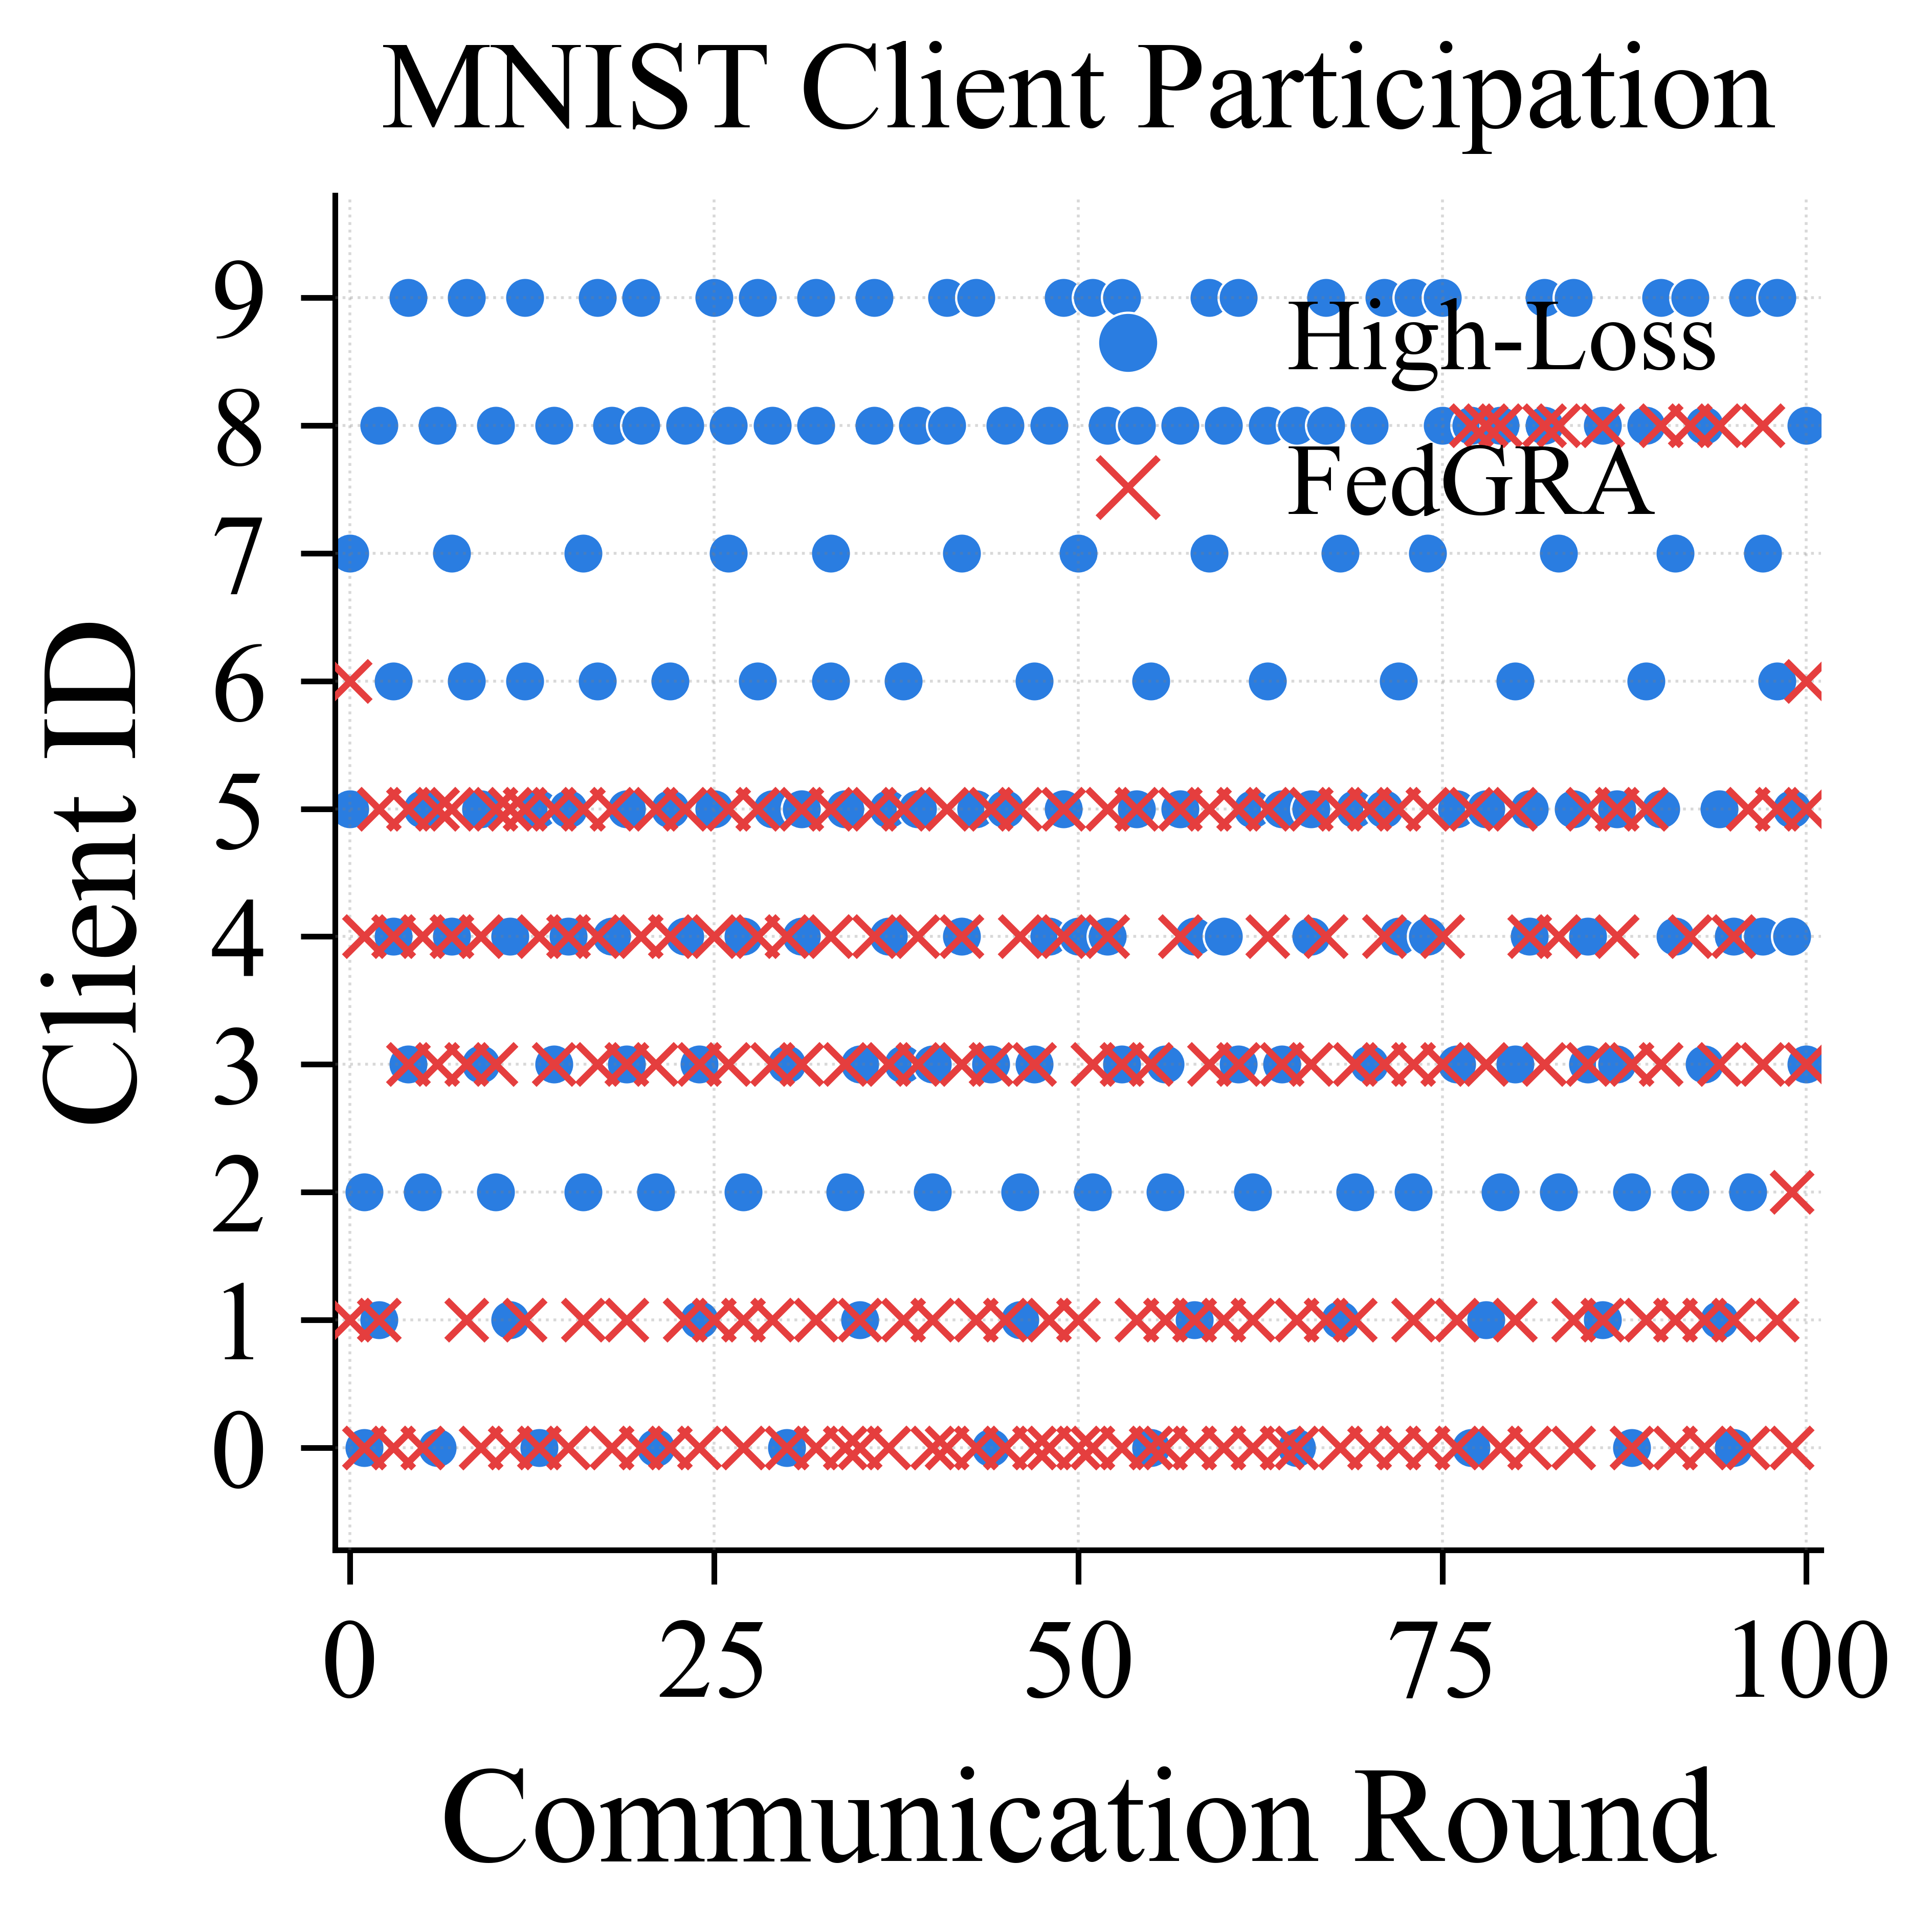

In [20]:
# ============================================================
# MNIST client participation
# ============================================================

plot_client_participation(
    participation_by_dataset["MNIST"],
    title="MNIST Client Participation",
    figsize=(5, 5),
    save_path="mnist_client_participation.pdf",
)


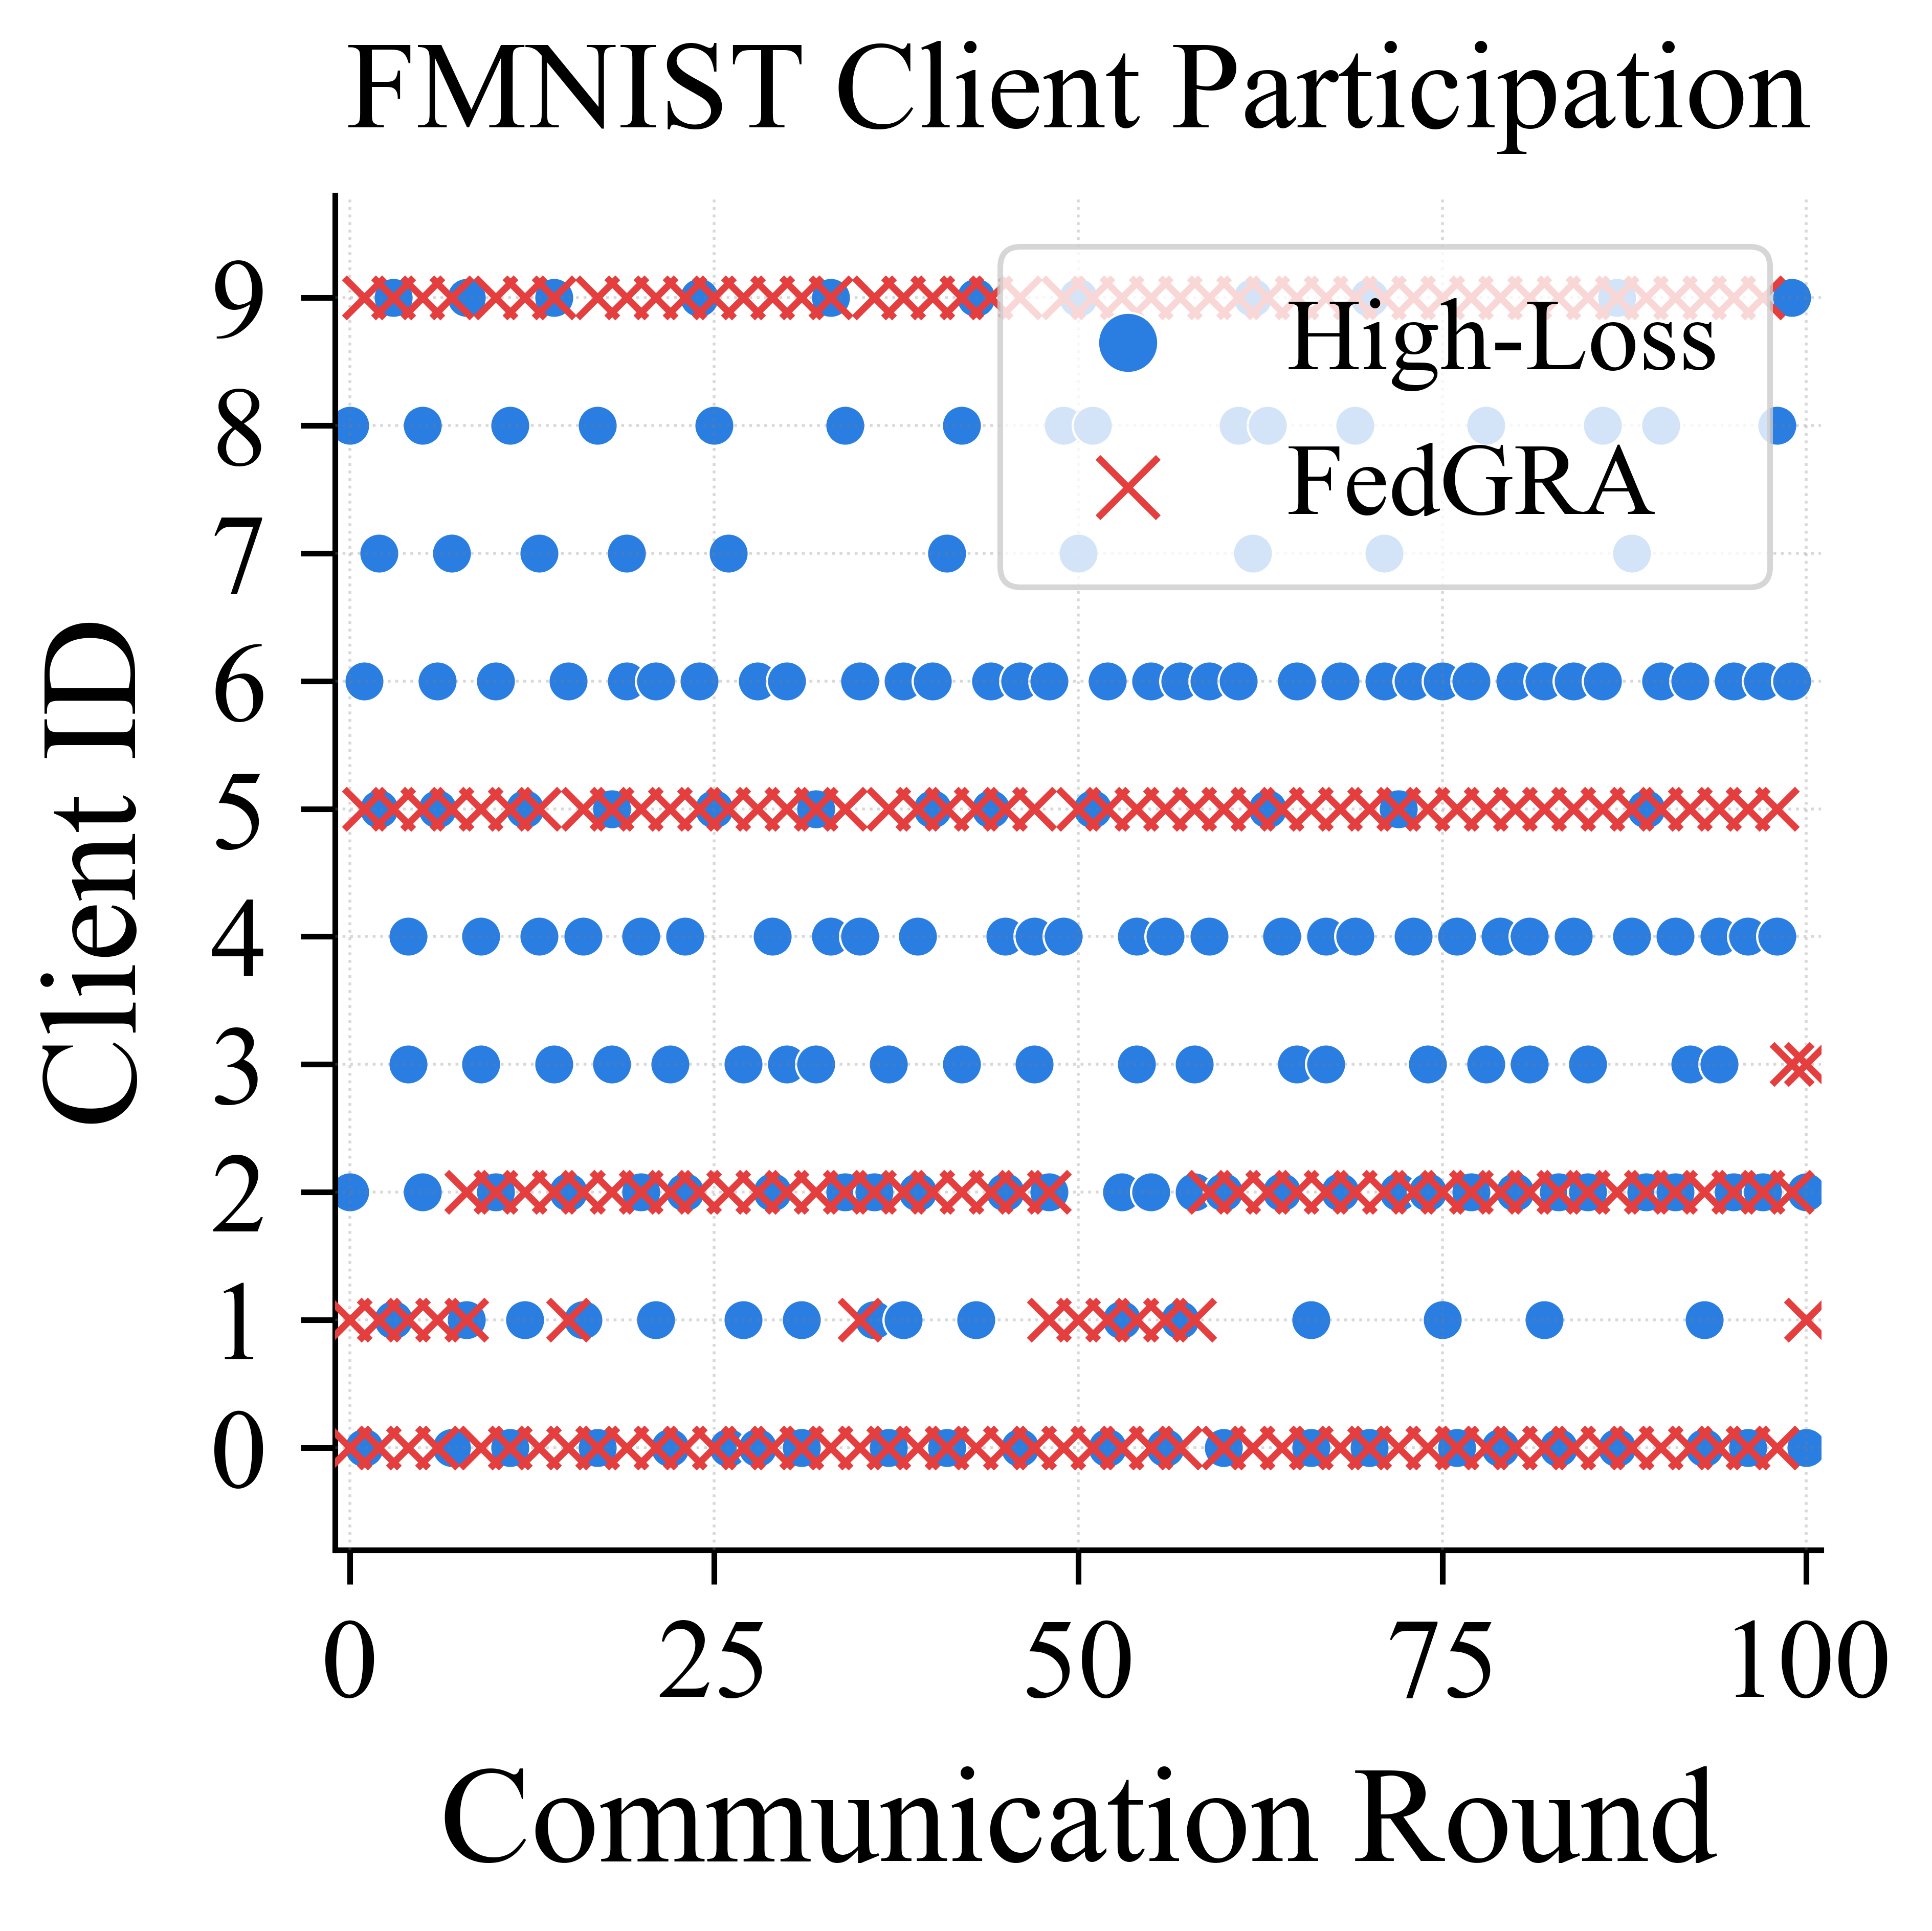

In [18]:
# ============================================================
# FMNIST client participation
# ============================================================

plot_client_participation(
    participation_by_dataset["FMNIST"],
    title="FMNIST Client Participation",
    figsize=(5, 5),
    save_path="fmnist_client_participation.pdf",
)


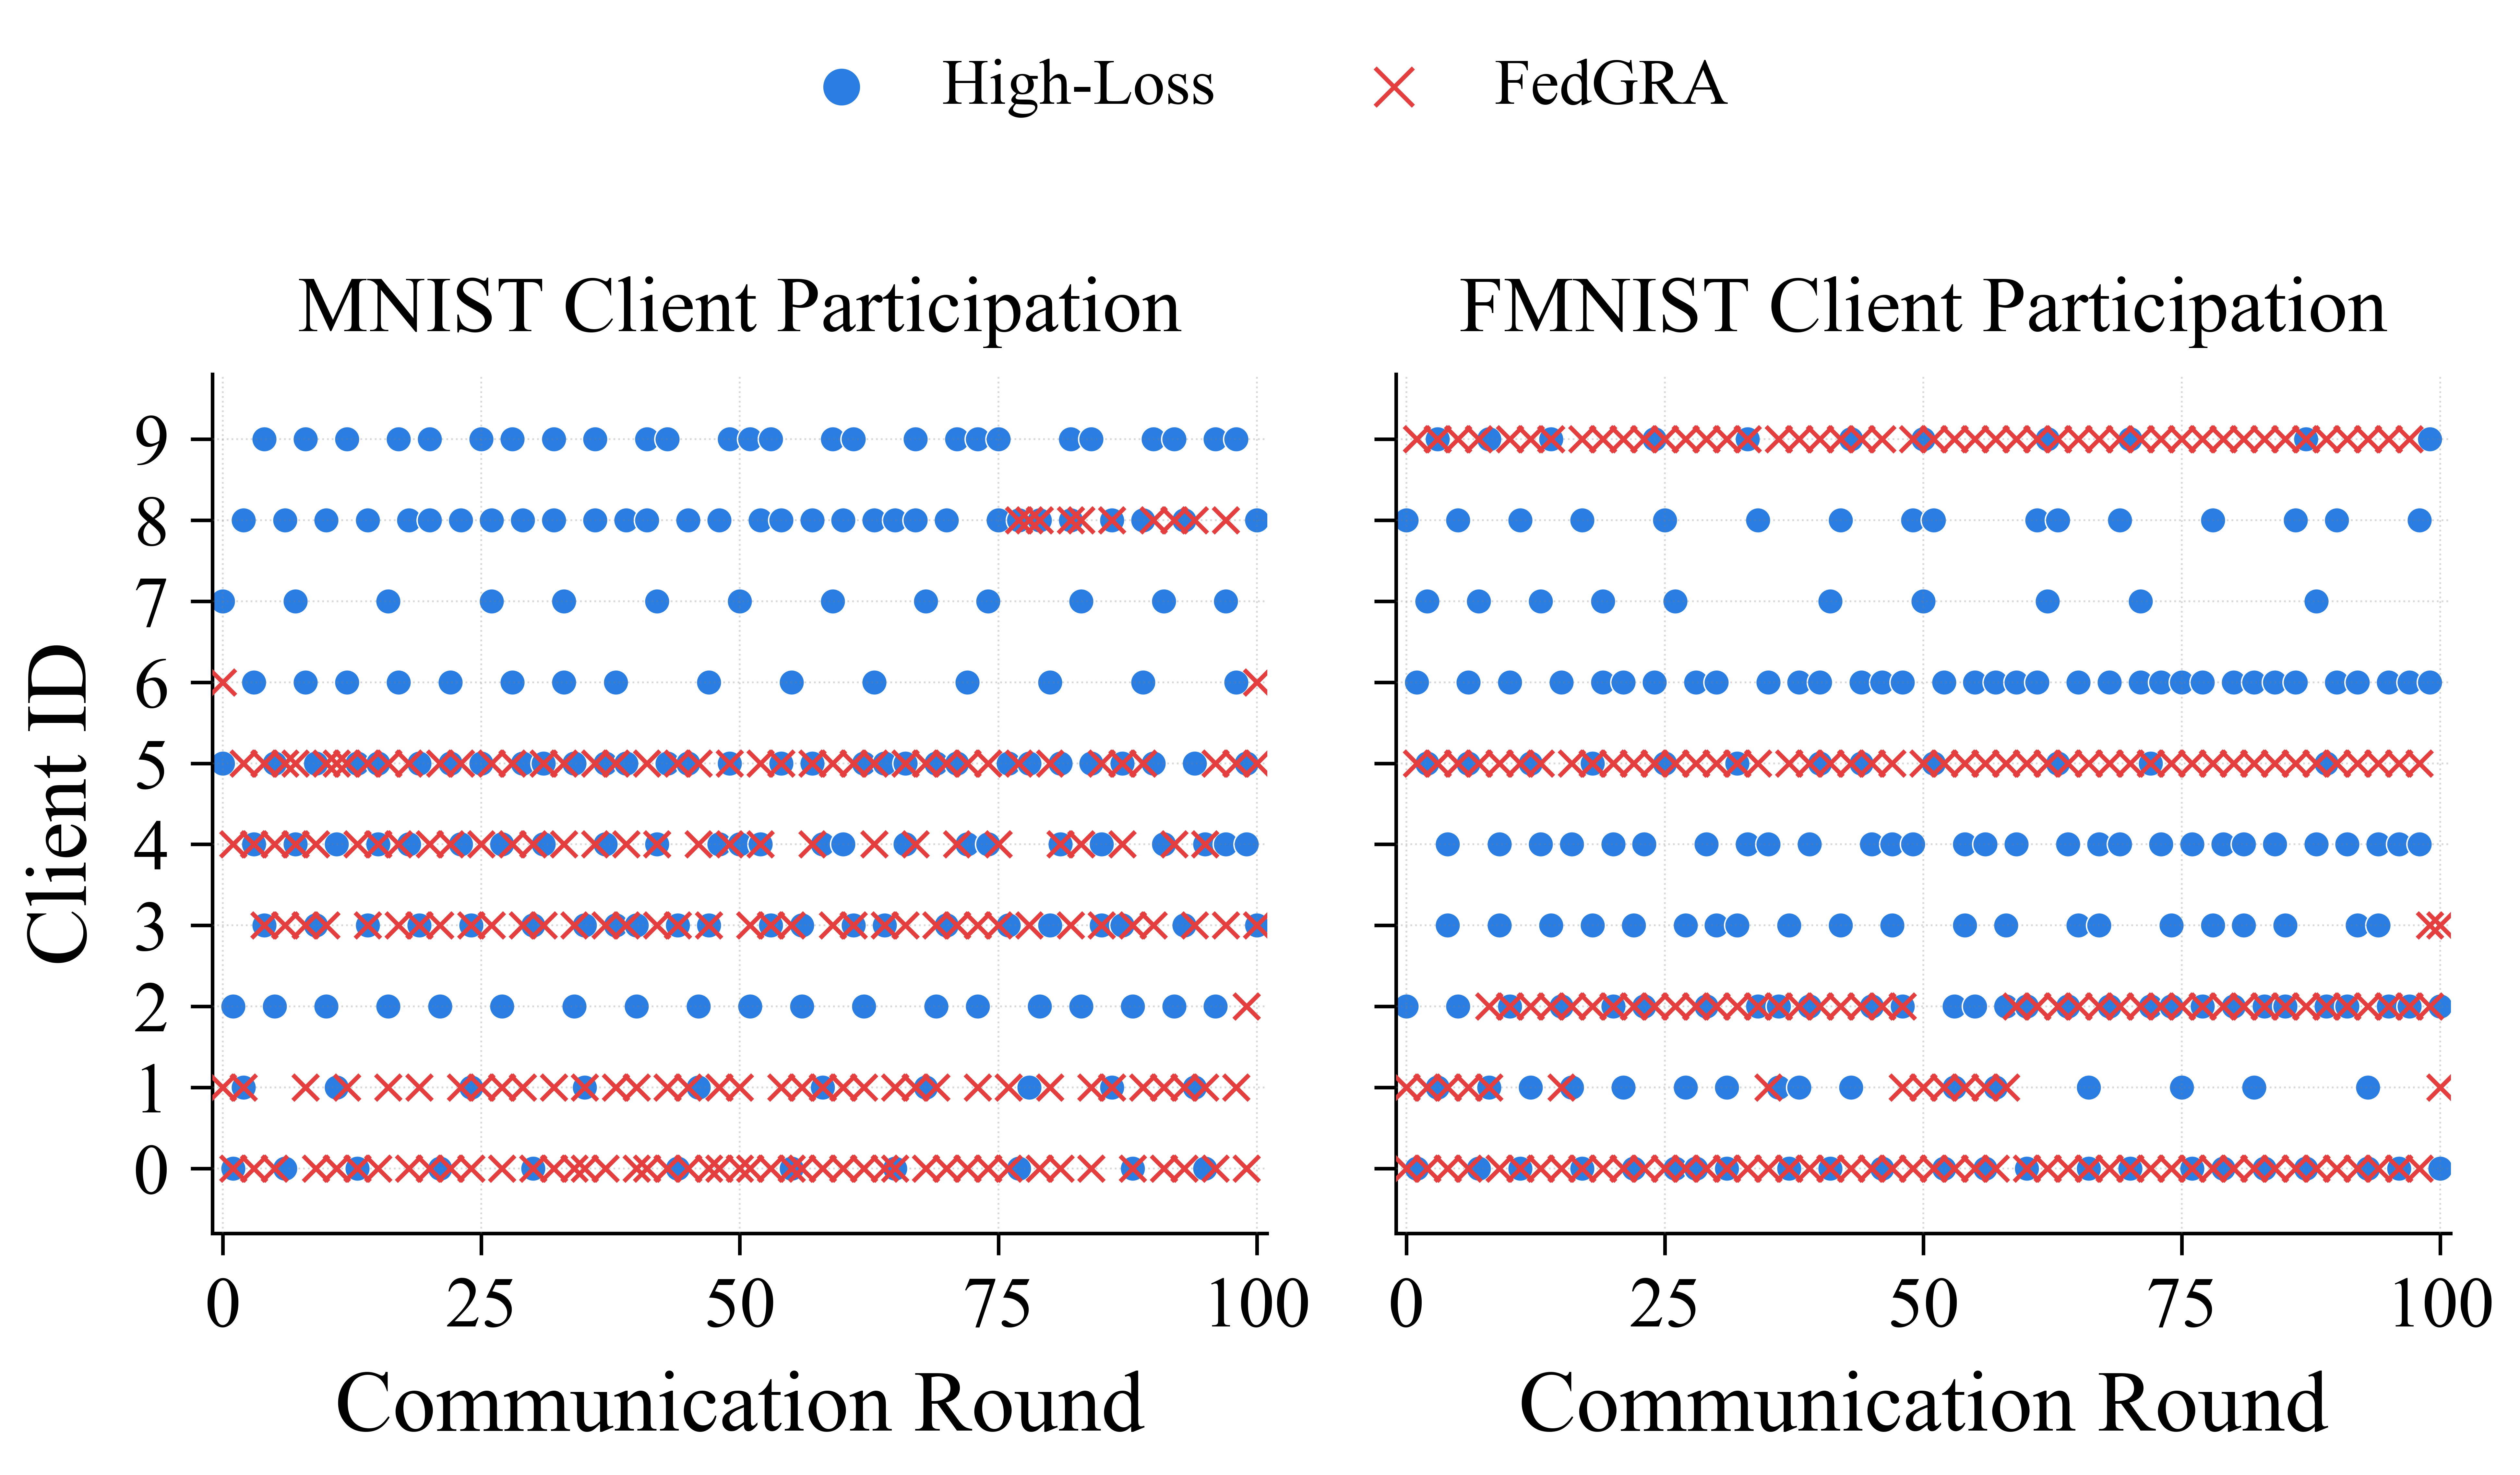

In [27]:
# ============================================================
# MNIST and FMNIST client participation, side by side
# ============================================================

plot_two_client_participation(
    participation_by_dataset,
    dataset_names=("MNIST", "FMNIST"),
    figsize=(10, 5),
    save_path="mnist_fmnist_client_participation.pdf",
)


In [ ]:
# ============================================================
# Heatmap/raster plot: High-Loss vs FedGRA participation
# ============================================================

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

def build_participation_heatmap(participation, n_clients=10, n_rounds=101):
    """Encode each cell as 0=None, 1=High-Loss, 2=FedGRA, 3=Both."""
    heatmap = np.zeros((n_clients, n_rounds), dtype=int)

    high_loss = participation["High-Loss"]
    for round_id, client_id in zip(high_loss["rounds"], high_loss["clients"]):
        if 0 <= client_id < n_clients and 0 <= round_id < n_rounds:
            heatmap[client_id, round_id] = 1

    fedgra = participation["FedGRA"]
    for round_id, client_id in zip(fedgra["rounds"], fedgra["clients"]):
        if 0 <= client_id < n_clients and 0 <= round_id < n_rounds:
            heatmap[client_id, round_id] = 3 if heatmap[client_id, round_id] == 1 else 2

    return heatmap

def plot_client_participation_heatmaps(
    participation_by_dataset,
    dataset_names=("MNIST", "FMNIST"),
    save_path=None,
    figsize=(11, 4.5),
    x_ticks=(0, 25, 50, 75, 100),
    legend_ncol=4,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.13),
):
    cmap = ListedColormap(["#edf2f7", "#2a7de1", "#e53e3e", "#7c3aed"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, axes = plt.subplots(1, len(dataset_names), figsize=figsize, sharey=True)
    if len(dataset_names) == 1:
        axes = [axes]

    for idx, (ax, dataset_name) in enumerate(zip(axes, dataset_names)):
        heatmap = build_participation_heatmap(participation_by_dataset[dataset_name])
        ax.imshow(
            heatmap,
            cmap=cmap,
            norm=norm,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            extent=(-0.5, 100.5, -0.5, 9.5),
        )

        ax.hlines(
            np.arange(-0.5, 10.5, 1),
            xmin=-0.5,
            xmax=100.5,
            color="white",
            linewidth=0.6,
            alpha=0.9,
        )
        ax.set_title(dataset_name, fontsize=22, pad=8)
        ax.set_xlabel("Communication Round", fontsize=22)
        if idx == 0:
            ax.set_ylabel("Client ID", fontsize=22)
        ax.set_xlim(-0.5, 100.5)
        ax.set_xticks(x_ticks)
        ax.set_ylim(-0.5, 9.5)
        ax.set_yticks(range(10))
        ax.tick_params(axis="x", labelsize=18)
        ax.tick_params(axis="y", labelsize=18)

    handles = [
        Patch(facecolor="#2a7de1", edgecolor="none", label="High-Loss only"),
        Patch(facecolor="#e53e3e", edgecolor="none", label="FedGRA only"),
        Patch(facecolor="#7c3aed", edgecolor="none", label="Both"),
        Patch(facecolor="#edf2f7", edgecolor="none", label="Not selected"),
    ]
    fig.legend(
        handles=handles,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox_to_anchor,
        ncol=legend_ncol,
        fontsize=16,
        frameon=False,
    )

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=800, bbox_inches="tight")
    plt.show()


In [ ]:
# ============================================================
# MNIST and FMNIST client participation heatmaps
# ============================================================

plot_client_participation_heatmaps(
    participation_by_dataset,
    dataset_names=("MNIST", "FMNIST"),
    figsize=(11, 4.5),
    save_path="mnist_fmnist_client_participation_heatmap.pdf",
)
